# Supervised Results Analysis

Analyze `data/results/supervised.csv` from the supervised runner. The notebook ranks supervised experiments, compares split strategies, checks validation-to-test movement, summarizes cross-validation stability, and inspects label/prediction distributions.

In [24]:
from pathlib import Path
import ast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 120)

candidate_paths = [Path("data/results/supervised.csv"), Path("../data/results/supervised.csv")]
DATA_PATH = next((path for path in candidate_paths if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Could not find data/results/supervised.csv from the current working directory.")

METRICS = ["accuracy", "f1", "recall", "precision", "fpr", "fnr", "tpr", "tnr", "auc", "fit_seconds"]
PRIMARY_METRIC = "f1" 

## Load Results

In [25]:
df = pd.read_csv(DATA_PATH)
df["fold"] = df["fold"].replace({"": np.nan})


def parse_counts(value):
    if pd.isna(value):
        return {}
    if isinstance(value, dict):
        return value
    return {str(k): int(v) for k, v in ast.literal_eval(value).items()}


df["label_counts_dict"] = df["label_counts"].map(parse_counts)
df["prediction_counts_dict"] = df["prediction_counts"].map(parse_counts)

print(f"Loaded {len(df):,} rows x {df.shape[1]:,} columns from {DATA_PATH}")
display(df.head())

Loaded 224 rows x 33 columns from ../data/results/supervised.csv


,experiment_name,split_method,evaluation,fold,model,model_config,model_experiment,training_mode,rows,accuracy,f1,recall,precision,fpr,fnr,tpr,tnr,auc,fit_seconds,accuracy_std,f1_std,recall_std,precision_std,fpr_std,fnr_std,tpr_std,tnr_std,auc_std,fit_seconds_std,label_counts,prediction_counts,label_counts_dict,prediction_counts_dict
0,regular__val__naive_bayes:default,regular,val,NaN,naive_bayes,default,naive_bayes:default,supervised,8520,0.8638,0.4357,0.3874,0.5793,0.0795,0.6126,0.3874,0.9205,0.8702,2.07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{""0"": 6375, ""1"": 1078, ""2"": 685, ""3"": 331, ""4""...","{""0"": 7272, ""1"": 909, ""2"": 202, ""3"": 137}","{'0': 6375, '1': 1078, '2': 685, '3': 331, '4'...","{'0': 7272, '1': 909, '2': 202, '3': 137}"
1,regular__test__naive_bayes:default,regular,test,NaN,naive_bayes,default,naive_bayes:default,supervised,8520,0.8662,0.4384,0.3892,0.5775,0.0768,0.6109,0.3892,0.9232,0.9024,2.03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{""0"": 6350, ""1"": 1140, ""2"": 716, ""3"": 277, ""4""...","{""0"": 7216, ""1"": 955, ""2"": 238, ""3"": 110, ""4"": 1}","{'0': 6350, '1': 1140, '2': 716, '3': 277, '4'...","{'0': 7216, '1': 955, '2': 238, '3': 110, '4': 1}"
2,regular__val__naive_bayes:high_smoothing,regular,val,NaN,naive_bayes,high_smoothing,naive_bayes:high_smoothing,supervised,8520,0.8445,0.3915,0.3425,0.5868,0.0958,0.6575,0.3425,0.9042,0.8377,2.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{""0"": 6375, ""1"": 1078, ""2"": 685, ""3"": 331, ""4""...","{""0"": 7540, ""1"": 745, ""2"": 130, ""3"": 105}","{'0': 6375, '1': 1078, '2': 685, '3': 331, '4'...","{'0': 7540, '1': 745, '2': 130, '3': 105}"
3,regular__test__naive_bayes:high_smoothing,regular,test,NaN,naive_bayes,high_smoothing,naive_bayes:high_smoothing,supervised,8520,0.8450,0.3907,0.3403,0.5884,0.0950,0.6597,0.3403,0.9050,0.8760,2.03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{""0"": 6350, ""1"": 1140, ""2"": 716, ""3"": 277, ""4""...","{""0"": 7518, ""1"": 768, ""2"": 155, ""3"": 79}","{'0': 6350, '1': 1140, '2': 716, '3': 277, '4'...","{'0': 7518, '1': 768, '2': 155, '3': 79}"
4,regular__val__naive_bayes:low_smoothing,regular,val,NaN,naive_bayes,low_smoothing,naive_bayes:low_smoothing,supervised,8520,0.8804,0.5605,0.5371,0.6182,0.0444,0.4629,0.5371,0.9556,0.9492,2.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{""0"": 6375, ""1"": 1078, ""2"": 685, ""3"": 331, ""4""...","{""0"": 6365, ""1"": 1211, ""2"": 668, ""3"": 258, ""4""...","{'0': 6375, '1': 1078, '2': 685, '3': 331, '4'...","{'0': 6365, '1': 1211, '2': 668, '3': 258, '4'..."


In [26]:
unique_counts = df.apply(lambda col: col.map(str).nunique(dropna=True) if col.dtype == "object" else col.nunique(dropna=True))

overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "unique": unique_counts,
})
display(overview)

display(
    df.groupby(["split_method", "evaluation"])
    .size()
    .rename("rows")
    .reset_index()
    .sort_values(["split_method", "evaluation"])
)

for col in ["split_method", "evaluation", "model", "model_config"]:
    print(f"\n{col}")
    display(df[col].value_counts(dropna=False).to_frame("count"))

,dtype,missing,unique
experiment_name,str,0,224
split_method,str,0,2
evaluation,str,0,4
fold,str,84,5
model,str,0,3
model_config,str,0,7
model_experiment,str,0,14
training_mode,str,0,1
rows,int64,0,4
accuracy,float64,0,170


,split_method,evaluation,rows
0,regular,fold_mean,14
1,regular,fold_val,70
2,regular,test,14
3,regular,val,14
4,stratified,fold_mean,14
5,stratified,fold_val,70
6,stratified,test,14
7,stratified,val,14



split_method


,count
split_method,
regular,112
stratified,112



evaluation


,count
evaluation,
fold_val,140
val,28
test,28
fold_mean,28



model


,count
model,
logistic_regression,80
linear_svc,80
naive_bayes,64



model_config


,count
model_config,
default,48
oversampled,48
balanced,32
strong_regularization,32
weak_regularization,32
high_smoothing,16
low_smoothing,16


## Best Validation and Test Experiments

Use `f1` as the default ranking metric because the task is imbalanced and accuracy can be dominated by the majority class. Change `PRIMARY_METRIC` in the first cell if a different ranking criterion is needed.

In [27]:
holdout = df[df["evaluation"].isin(["val", "test"])].copy()
rank_cols = ["evaluation", "split_method", "model", "model_config", "model_experiment", "rows"] + METRICS

best_by_eval = (
    holdout.sort_values(["evaluation", PRIMARY_METRIC, "auc"], ascending=[True, False, False])
    .groupby("evaluation", as_index=False)
    .head(10)[rank_cols]
)

display(best_by_eval.round({metric: 4 for metric in METRICS}))

,evaluation,split_method,model,model_config,model_experiment,rows,accuracy,f1,recall,precision,fpr,fnr,tpr,tnr,auc,fit_seconds
19,test,regular,linear_svc,balanced,linear_svc:balanced,8520,0.9085,0.8098,0.8339,0.7936,0.0326,0.1661,0.8338,0.9674,NaN,5.35
17,test,regular,logistic_regression,weak_regularization,logistic_regression:weak_regularization,8520,0.9126,0.8058,0.7758,0.8422,0.0387,0.2242,0.7758,0.9613,NaN,23.45
21,test,regular,linear_svc,default,linear_svc:default,8520,0.9134,0.8032,0.7728,0.8409,0.0378,0.2272,0.7728,0.9622,NaN,3.94
23,test,regular,linear_svc,oversampled,linear_svc:oversampled,8520,0.9004,0.8000,0.8287,0.7791,0.0343,0.1714,0.8286,0.9657,NaN,97.87
13,test,regular,logistic_regression,oversampled,logistic_regression:oversampled,8520,0.8999,0.7924,0.8554,0.7549,0.0298,0.1446,0.8554,0.9702,NaN,45.17
27,test,regular,linear_svc,weak_regularization,linear_svc:weak_regularization,8520,0.9027,0.7902,0.7745,0.8079,0.0385,0.2255,0.7745,0.9615,NaN,14.09
25,test,regular,linear_svc,strong_regularization,linear_svc:strong_regularization,8520,0.9089,0.7751,0.7249,0.8533,0.0450,0.2751,0.7250,0.9550,NaN,2.88
131,test,stratified,linear_svc,balanced,linear_svc:balanced,8520,0.9002,0.7401,0.7537,0.7303,0.0353,0.2463,0.7537,0.9647,NaN,2.72
139,test,stratified,linear_svc,weak_regularization,linear_svc:weak_regularization,8520,0.8945,0.7337,0.7116,0.7605,0.0417,0.2884,0.7115,0.9583,NaN,103.69
135,test,stratified,linear_svc,oversampled,linear_svc:oversampled,8520,0.8920,0.7184,0.7638,0.6861,0.0362,0.2362,0.7638,0.9638,NaN,970.76


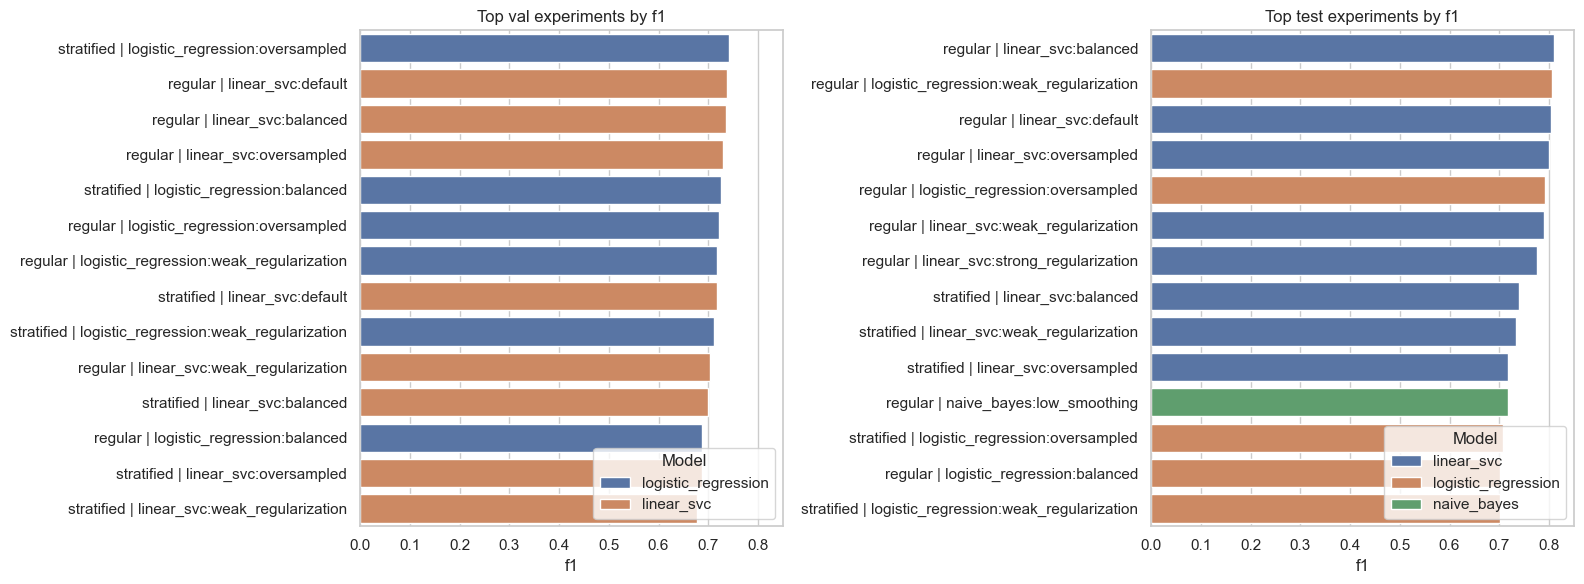

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
for ax, evaluation in zip(axes, ["val", "test"]):
    plot_df = (
        holdout[holdout["evaluation"].eq(evaluation)]
        .sort_values(PRIMARY_METRIC, ascending=False)
        .head(14)
        .assign(label=lambda x: x["split_method"] + " | " + x["model_experiment"])
    )
    sns.barplot(data=plot_df, y="label", x=PRIMARY_METRIC, hue="model", dodge=False, ax=ax)
    ax.set_title(f"Top {evaluation} experiments by {PRIMARY_METRIC}")
    ax.set_xlabel(PRIMARY_METRIC)
    ax.set_ylabel("")
    ax.legend(title="Model", loc="lower right")
plt.tight_layout()

## Model and Split Comparison

In [29]:
summary = (
    holdout.groupby(["evaluation", "split_method", "model"], as_index=False)[METRICS]
    .agg(["mean", "max", "std"])
)
summary.columns = ["_".join(col).strip("_") for col in summary.columns.to_flat_index()]
display(summary.sort_values(["evaluation", f"{PRIMARY_METRIC}_max"], ascending=[True, False]))

,evaluation,split_method,model,accuracy_mean,accuracy_max,accuracy_std,f1_mean,f1_max,f1_std,recall_mean,recall_max,recall_std,precision_mean,precision_max,precision_std,fpr_mean,fpr_max,fpr_std,fnr_mean,fnr_max,fnr_std,tpr_mean,tpr_max,tpr_std,tnr_mean,tnr_max,tnr_std,auc_mean,auc_max,auc_std,fit_seconds_mean,fit_seconds_max,fit_seconds_std
0,test,regular,linear_svc,0.906780,0.9134,0.005211,0.795660,0.8098,0.013492,0.786960,0.8339,0.045146,0.814960,0.8533,0.031364,0.037640,0.0450,0.004783,0.213060,0.2751,0.045123,0.786940,0.8338,0.045063,0.962360,0.9674,0.004783,NaN,NaN,NaN,24.8260,97.87,41.072662
1,test,regular,logistic_regression,0.899120,0.9126,0.013958,0.691420,0.8058,0.120153,0.714220,0.8818,0.182725,0.716140,0.8422,0.084420,0.041680,0.0688,0.016077,0.285740,0.5520,0.182674,0.714240,0.8818,0.182688,0.958320,0.9705,0.016077,NaN,NaN,NaN,23.2520,45.17,13.107659
3,test,stratified,linear_svc,0.899000,0.9055,0.005643,0.694960,0.7401,0.059994,0.683680,0.7638,0.091832,0.720560,0.7605,0.034167,0.040320,0.0477,0.004967,0.316320,0.4591,0.091832,0.683660,0.7638,0.091824,0.959680,0.9647,0.004967,NaN,NaN,NaN,216.2200,970.76,424.083267
2,test,regular,naive_bayes,0.836275,0.8859,0.061174,0.503850,0.7171,0.145788,0.568925,0.8434,0.243468,0.585775,0.7570,0.137609,0.065825,0.0950,0.024637,0.431100,0.6597,0.243492,0.568925,0.8434,0.243468,0.934175,0.9589,0.024637,0.924325,0.9601,0.041970,2.0475,2.11,0.041932
4,test,stratified,logistic_regression,0.892840,0.9066,0.013017,0.644360,0.7080,0.085178,0.658580,0.8296,0.164039,0.691040,0.8244,0.077366,0.043580,0.0693,0.015778,0.341420,0.5544,0.164039,0.658580,0.8296,0.163983,0.956420,0.9693,0.015778,NaN,NaN,NaN,32.6440,109.56,43.494567
5,test,stratified,naive_bayes,0.833175,0.8822,0.060325,0.483275,0.6405,0.112514,0.536425,0.8364,0.229169,0.585275,0.7861,0.149144,0.067175,0.0960,0.024943,0.463575,0.6644,0.229169,0.536425,0.8364,0.229169,0.932825,0.9577,0.024943,0.906400,0.9564,0.053409,1.1875,1.24,0.035000
10,val,stratified,logistic_regression,0.896620,0.9117,0.013685,0.655780,0.7418,0.101987,0.648120,0.8101,0.162156,0.726240,0.8561,0.073774,0.043360,0.0699,0.016109,0.351880,0.5600,0.162156,0.648120,0.8101,0.162156,0.956640,0.9695,0.016109,NaN,NaN,NaN,47.2520,134.29,56.336908
6,val,regular,linear_svc,0.903220,0.9079,0.003941,0.701860,0.7378,0.057077,0.734460,0.8121,0.108637,0.712740,0.7593,0.027930,0.040360,0.0500,0.006596,0.265540,0.4518,0.108637,0.734460,0.8121,0.108637,0.959640,0.9661,0.006596,NaN,NaN,NaN,25.0880,98.94,41.530362
7,val,regular,logistic_regression,0.894060,0.9054,0.012032,0.649500,0.7217,0.088809,0.675860,0.8728,0.187985,0.699100,0.8478,0.087348,0.044980,0.0701,0.016066,0.324140,0.5523,0.187985,0.675900,0.8729,0.187995,0.954980,0.9690,0.016049,NaN,NaN,NaN,221.7140,1010.04,440.877555
9,val,stratified,linear_svc,0.905140,0.9099,0.004035,0.691220,0.7168,0.017477,0.659460,0.6921,0.042240,0.753360,0.8615,0.064481,0.039100,0.0472,0.005224,0.340540,0.4102,0.042240,0.659460,0.6921,0.042240,0.960900,0.9656,0.005224,NaN,NaN,NaN,50.9500,239.71,105.553462


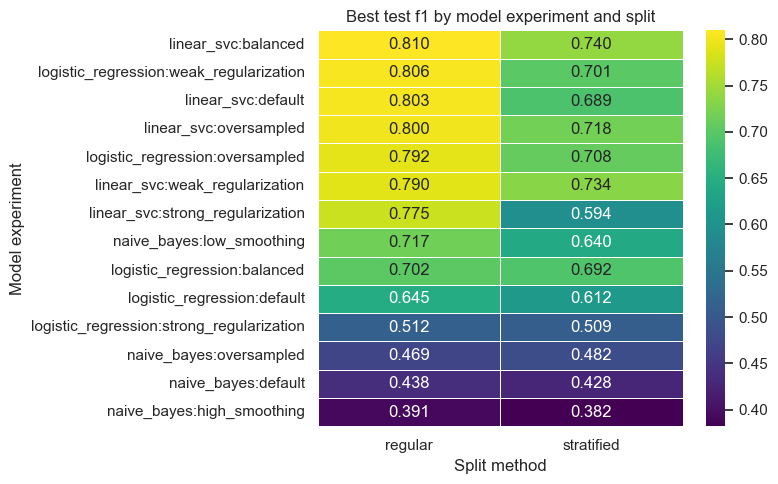

In [30]:
heatmap_data = (
    holdout[holdout["evaluation"].eq("test")]
    .pivot_table(index="model_experiment", columns="split_method", values=PRIMARY_METRIC, aggfunc="max")
)
heatmap_data = heatmap_data.assign(best=heatmap_data.max(axis=1)).sort_values("best", ascending=False).drop(columns="best")

plt.figure(figsize=(8, max(5, 0.35 * len(heatmap_data))))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="viridis", linewidths=0.5)
plt.title(f"Best test {PRIMARY_METRIC} by model experiment and split")
plt.xlabel("Split method")
plt.ylabel("Model experiment")
plt.tight_layout()

## Validation-to-Test Movement

In [31]:
paired = holdout.pivot_table(
    index=["split_method", "model", "model_config", "model_experiment"],
    columns="evaluation",
    values=METRICS,
    aggfunc="first",
)
paired.columns = [f"{metric}_{evaluation}" for metric, evaluation in paired.columns]
paired = paired.reset_index()

for metric in ["accuracy", "f1", "recall", "precision", "fpr", "auc"]:
    if f"{metric}_test" in paired and f"{metric}_val" in paired:
        paired[f"{metric}_delta_test_minus_val"] = paired[f"{metric}_test"] - paired[f"{metric}_val"]

movement_cols = ["split_method", "model", "model_config", "model_experiment", "f1_val", "f1_test", "f1_delta_test_minus_val", "auc_val", "auc_test", "auc_delta_test_minus_val"]
display(paired[movement_cols].sort_values("f1_test", ascending=False).round(4))

,split_method,model,model_config,model_experiment,f1_val,f1_test,f1_delta_test_minus_val,auc_val,auc_test,auc_delta_test_minus_val
0,regular,linear_svc,balanced,linear_svc:balanced,0.7356,0.8098,0.0742,NaN,NaN,NaN
9,regular,logistic_regression,weak_regularization,logistic_regression:weak_regularization,0.7177,0.8058,0.0881,NaN,NaN,NaN
1,regular,linear_svc,default,linear_svc:default,0.7378,0.8032,0.0654,NaN,NaN,NaN
2,regular,linear_svc,oversampled,linear_svc:oversampled,0.7299,0.8000,0.0701,NaN,NaN,NaN
7,regular,logistic_regression,oversampled,logistic_regression:oversampled,0.7217,0.7924,0.0707,NaN,NaN,NaN
4,regular,linear_svc,weak_regularization,linear_svc:weak_regularization,0.7032,0.7902,0.0870,NaN,NaN,NaN
3,regular,linear_svc,strong_regularization,linear_svc:strong_regularization,0.6028,0.7751,0.1723,NaN,NaN,NaN
14,stratified,linear_svc,balanced,linear_svc:balanced,0.6997,0.7401,0.0404,NaN,NaN,NaN
18,stratified,linear_svc,weak_regularization,linear_svc:weak_regularization,0.6783,0.7337,0.0554,NaN,NaN,NaN
16,stratified,linear_svc,oversampled,linear_svc:oversampled,0.6879,0.7184,0.0305,NaN,NaN,NaN


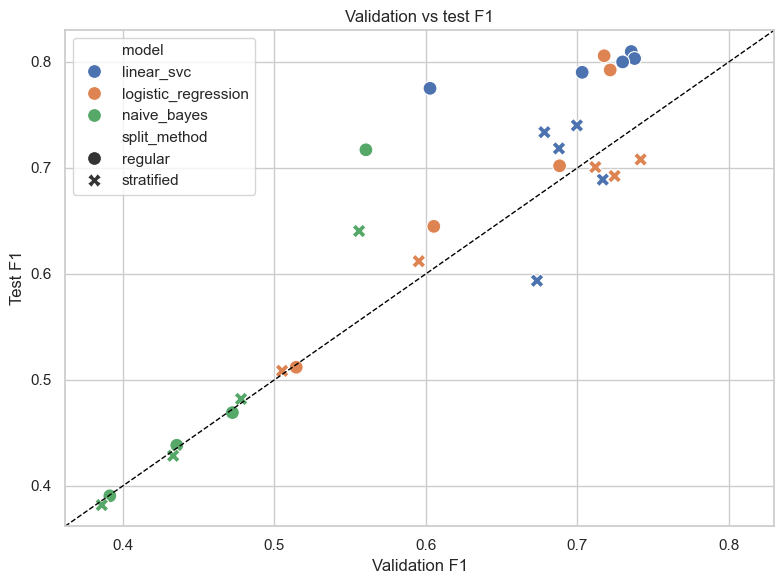

In [32]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=paired, x="f1_val", y="f1_test", hue="model", style="split_method", s=100)
limit_min = min(paired["f1_val"].min(), paired["f1_test"].min()) - 0.02
limit_max = max(paired["f1_val"].max(), paired["f1_test"].max()) + 0.02
plt.plot([limit_min, limit_max], [limit_min, limit_max], color="black", linestyle="--", linewidth=1)
plt.xlim(limit_min, limit_max)
plt.ylim(limit_min, limit_max)
plt.title("Validation vs test F1")
plt.xlabel("Validation F1")
plt.ylabel("Test F1")
plt.tight_layout()

## Cross-Validation Stability

In [33]:
fold_rows = df[df["evaluation"].eq("fold_val")].copy()

fold_summary = (
    fold_rows.groupby(["split_method", "model", "model_config", "model_experiment"], as_index=False)
    .agg(
        folds=("fold", "nunique"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
        f1_min=("f1", "min"),
        f1_max=("f1", "max"),
        auc_mean=("auc", "mean"),
        auc_std=("auc", "std"),
        fit_seconds_mean=("fit_seconds", "mean"),
    )
    .sort_values(["f1_mean", "auc_mean"], ascending=False)
)

display(fold_summary.round({
    "f1_mean": 4, "f1_std": 4, "f1_min": 4, "f1_max": 4,
    "auc_mean": 4, "auc_std": 4, "fit_seconds_mean": 2,
}))

,split_method,model,model_config,model_experiment,folds,f1_mean,f1_std,f1_min,f1_max,auc_mean,auc_std,fit_seconds_mean
21,stratified,logistic_regression,oversampled,logistic_regression:oversampled,5,0.7361,0.0040,0.7314,0.7410,NaN,NaN,24.21
0,regular,linear_svc,balanced,linear_svc:balanced,5,0.7346,0.0206,0.7080,0.7560,NaN,NaN,4.82
2,regular,linear_svc,oversampled,linear_svc:oversampled,5,0.7312,0.0183,0.7109,0.7497,NaN,NaN,90.04
14,stratified,linear_svc,balanced,linear_svc:balanced,5,0.7294,0.0203,0.7046,0.7527,NaN,NaN,2.79
16,stratified,linear_svc,oversampled,linear_svc:oversampled,5,0.7292,0.0181,0.7120,0.7490,NaN,NaN,58.22
7,regular,logistic_regression,oversampled,logistic_regression:oversampled,5,0.7264,0.0120,0.7099,0.7379,NaN,NaN,346.51
1,regular,linear_svc,default,linear_svc:default,5,0.7258,0.0171,0.7025,0.7418,NaN,NaN,3.90
19,stratified,logistic_regression,balanced,logistic_regression:balanced,5,0.7151,0.0089,0.7036,0.7263,NaN,NaN,11.83
5,regular,logistic_regression,balanced,logistic_regression:balanced,5,0.7131,0.0151,0.6938,0.7275,NaN,NaN,17.57
15,stratified,linear_svc,default,linear_svc:default,5,0.7126,0.0152,0.6939,0.7333,NaN,NaN,2.23


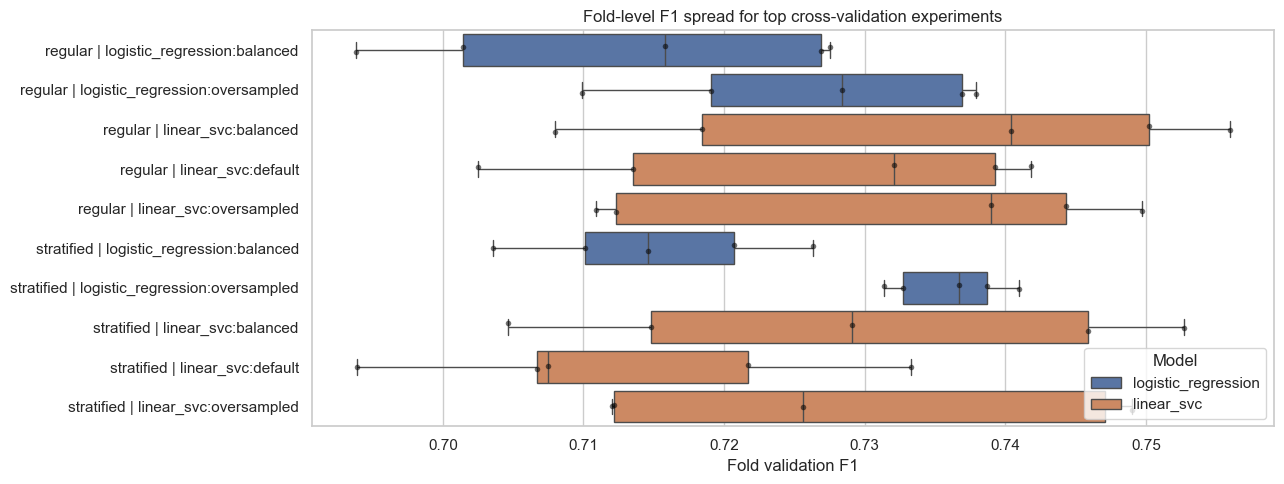

In [34]:
top_fold_experiments = fold_summary.head(10)["model_experiment"].tolist()
plot_df = fold_rows[fold_rows["model_experiment"].isin(top_fold_experiments)].copy()
plot_df["label"] = plot_df["split_method"] + " | " + plot_df["model_experiment"]

plt.figure(figsize=(13, max(5, 0.4 * plot_df["label"].nunique())))
sns.boxplot(data=plot_df, y="label", x="f1", hue="model", dodge=False)
sns.stripplot(data=plot_df, y="label", x="f1", color="black", size=4, alpha=0.55)
plt.title("Fold-level F1 spread for top cross-validation experiments")
plt.xlabel("Fold validation F1")
plt.ylabel("")
plt.legend(title="Model", loc="lower right")
plt.tight_layout()

## Metric Tradeoffs

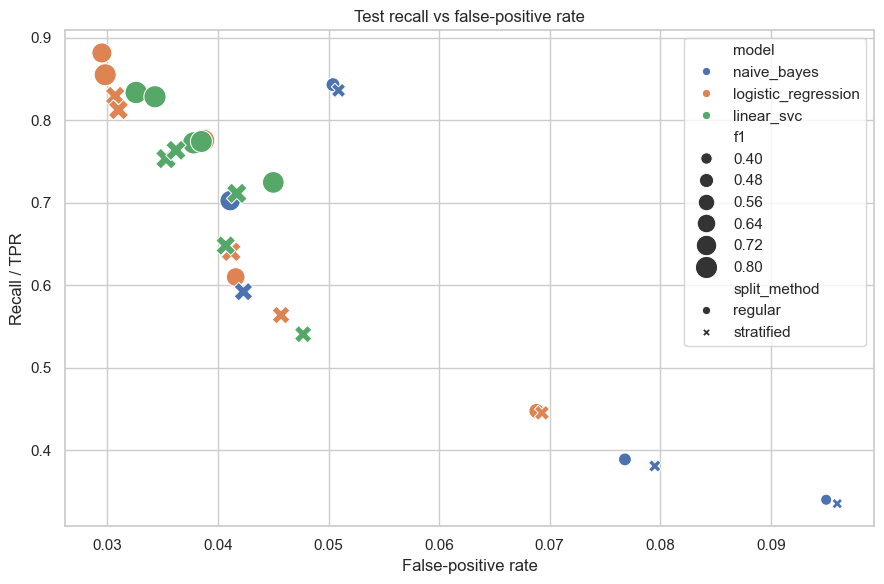

In [35]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=holdout[holdout["evaluation"].eq("test")],
    x="fpr",
    y="recall",
    size="f1",
    hue="model",
    style="split_method",
    sizes=(60, 260),
)
plt.title("Test recall vs false-positive rate")
plt.xlabel("False-positive rate")
plt.ylabel("Recall / TPR")
plt.tight_layout()

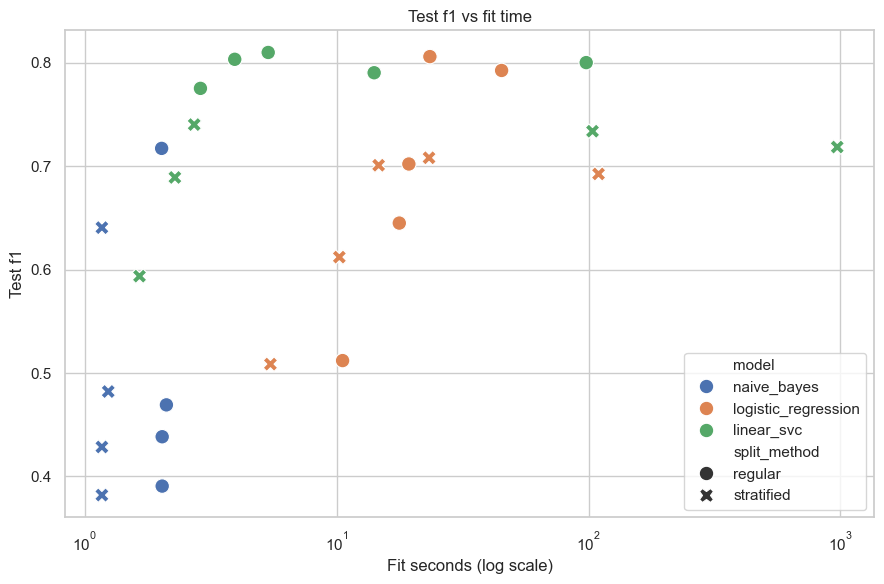

In [36]:
speed_quality = holdout[holdout["evaluation"].eq("test")].copy()
plt.figure(figsize=(9, 6))
sns.scatterplot(data=speed_quality, x="fit_seconds", y=PRIMARY_METRIC, hue="model", style="split_method", s=110)
plt.xscale("log")
plt.title(f"Test {PRIMARY_METRIC} vs fit time")
plt.xlabel("Fit seconds (log scale)")
plt.ylabel(f"Test {PRIMARY_METRIC}")
plt.tight_layout()

## Label and Prediction Distributions

In [37]:
def counts_to_frame(source_df, counts_col, kind):
    rows = []
    for _, row in source_df.iterrows():
        total = sum(row[counts_col].values())
        for label, count in row[counts_col].items():
            rows.append({
                "evaluation": row["evaluation"],
                "split_method": row["split_method"],
                "model": row["model"],
                "model_config": row["model_config"],
                "model_experiment": row["model_experiment"],
                "label": str(label),
                "count": count,
                "share": count / total if total else np.nan,
                "kind": kind,
            })
    return pd.DataFrame(rows)

best_tests = holdout[holdout["evaluation"].eq("test")].sort_values(PRIMARY_METRIC, ascending=False).head(6)

dist_df = pd.concat([
    counts_to_frame(best_tests, "label_counts_dict", "actual"),
    counts_to_frame(best_tests, "prediction_counts_dict", "predicted"),
], ignore_index=True)

display(dist_df.head())

,evaluation,split_method,model,model_config,model_experiment,label,count,share,kind
0,test,regular,linear_svc,balanced,linear_svc:balanced,0,6350,0.745305,actual
1,test,regular,linear_svc,balanced,linear_svc:balanced,1,1140,0.133803,actual
2,test,regular,linear_svc,balanced,linear_svc:balanced,2,716,0.084038,actual
3,test,regular,linear_svc,balanced,linear_svc:balanced,3,277,0.032512,actual
4,test,regular,linear_svc,balanced,linear_svc:balanced,4,36,0.004225,actual


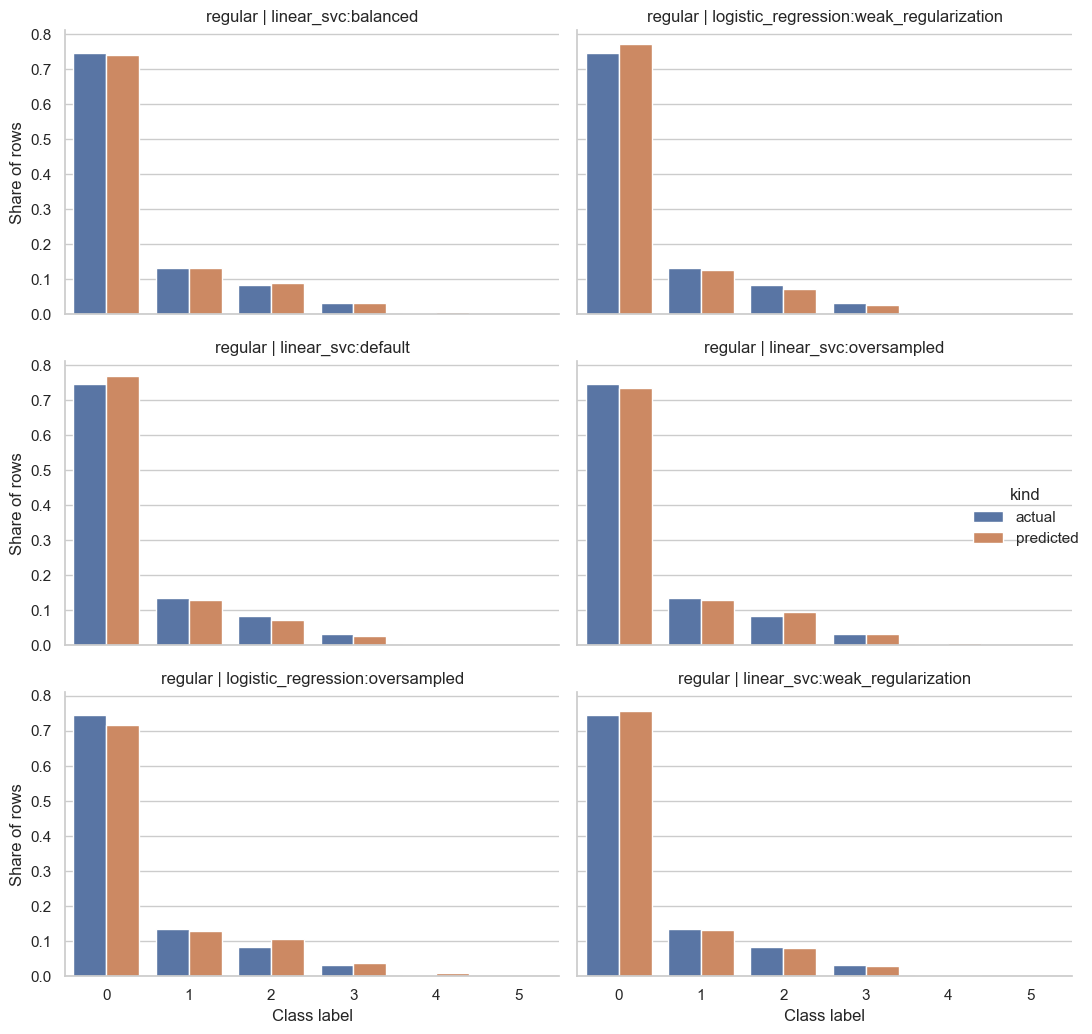

In [38]:
plot_df = dist_df.copy()
plot_df["experiment"] = plot_df["split_method"] + " | " + plot_df["model_experiment"]

g = sns.catplot(
    data=plot_df,
    kind="bar",
    x="label",
    y="share",
    hue="kind",
    col="experiment",
    col_wrap=2,
    height=3.5,
    aspect=1.4,
    sharey=True,
)
g.set_axis_labels("Class label", "Share of rows")
g.set_titles("{col_name}")
for ax in g.axes.flatten():
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()

## Takeaways Template

Final interpretation:

- Best validation experiment:
- Best test experiment:
- Most stable cross-validation experiment:
- Main precision/recall tradeoff:
- Any evidence that validation selection does not transfer to test: